# Dependencies

In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn


In [86]:
# pandas and NumPy
import pandas as pd
import numpy as np

# Seaborn and matplotlib for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression 
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn import svm


# K-Means clustering
from sklearn.cluster import KMeans

# Train / test split
from sklearn.model_selection import train_test_split

# Metrics
from sklearn import metrics



# 1. Data pre-processing


In [87]:
df = pd.read_csv('laptops_data.csv')

df.head()

,Unnamed: 0,Name,Discounted Price,Actual Price,Saving,Rating,Reviews,Brand,Core,SSD,Model
0,0,Apple MacBook Air 13 M1 MGN63 (8GB-256GB),203499.0,258000.0,21% OFF,5.0,2.0,Apple,M1,NaN,MacBook Air 13 M1 MGN63
1,1,Apple Macbook Air 13 MW123 M4 Chip,281999.0,350000.0,19% OFF,4.3,5.0,Apple,M4,NaN,Macbook Air 13 MW123 M4 Chip
2,2,ASUS Zenbook 14 UX3405CA Intel Core Ultra 7 25...,285999.0,330000.0,13% OFF,NaN,NaN,ASUS,Ultra 7,16GB-512GB SSD,Zenbook 14 UX3405CA Intel Core Ultra 7 255H
3,3,Lenovo ThinkPad E16 Gen 2 - Intel Core Ultra 7...,287999.0,340000.0,15% OFF,NaN,NaN,Lenovo,Ultra 7,NaN,ThinkPad E16 Gen 2 - Intel Core Ultra 7
4,4,Lenovo IdeaPad Slim 3 Ryzen 7 (8GB-512GB),146999.0,175000.0,16% OFF,NaN,NaN,Lenovo,Ryzen 7,NaN,IdeaPad Slim 3 Ryzen 7


In [88]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        306 non-null    int64  
 1   Name              306 non-null    object 
 2   Discounted Price  306 non-null    float64
 3   Actual Price      291 non-null    float64
 4   Saving            291 non-null    object 
 5   Rating            26 non-null     float64
 6   Reviews           26 non-null     float64
 7   Brand             306 non-null    object 
 8   Core              219 non-null    object 
 9   SSD               92 non-null     object 
 10  Model             306 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 26.4+ KB
None


In [89]:
df.isnull().mean() * 100


Unnamed: 0           0.000000
Name                 0.000000
Discounted Price     0.000000
Actual Price         4.901961
Saving               4.901961
Rating              91.503268
Reviews             91.503268
Brand                0.000000
Core                28.431373
SSD                 69.934641
Model                0.000000
dtype: float64

- Rating and Reviews contain a high proportion of missing values and cannot be reliably imputed, so these columns are removed.

- The first column is unnamed and corresponds to an automatically generated CSV index, so it is dropped.

- The Name column contains multiple technical specifications in a single string. Since the Model column already stores the model name, we extract RAM and storage capacity from Name into two new columns (RAM_GB and Storage_GB).

- The SSD column is inconsistent: many laptops that clearly contain SSD storage do not have this information filled. Therefore, storage information is systematically extracted from Name, and the SSD column is removed.

- After feature extraction, the Name column becomes redundant and is therefore removed.

PS : Prices in this dataset are expressed in Indian Rupees (INR).

In [90]:
df1 = df.iloc[:, 1:].copy() 
# RAM and storage extraction 

# the specs are in parantheses, so we start by extracting what's inside them
# Extract only parentheses containing GB (RAM + Storage), because some name models have parentheses like Infinix INBOOK Air (XL442) Core i3 1215U (8GB - 256GB)
specs = df1['Name'].str.extract(r'\(([^)]*GB[^)]*)\)', expand=False)

# Split on first GB
split_specs = specs.str.split(r'GB', n=1, expand=True)

# RAM (left part)
df1['RAM_GB'] = split_specs[0].str.extract(r'(\d+)').astype(float)

# Storage (right part)
storage = split_specs[1].str.extract(r'(\d+)\s*(TB|GB)', expand=True)

df1['Storage_GB'] = np.where(
    storage[1] == 'TB',
    storage[0].astype(float) * 1024,
    storage[0].astype(float)
)

# Saving extraction (%)
df1['Saving_percent'] = (
    df1['Saving']
    .str.extract(r'(\d+)')
    .astype(float)
)

# Clean categorical columns
for col in ['Brand', 'Core']:
    df1[col] = (
        df1[col]
        .str.lower()
        .str.replace(' ', '', regex=False)
        .str.replace('-', '', regex=False)
    )

# Fill missing values (quantitative columns) with median
for col in ['RAM_GB', 'Storage_GB', 'Saving_percent', 'Actual Price']:
    df1[col] = df1[col].fillna(df1[col].median())


# Drop useless columns
df1 = df1.drop(columns=['Name','Rating', 'Reviews', 'SSD', 'Saving'])

df1.head(10)


,Discounted Price,Actual Price,Brand,Core,Model,RAM_GB,Storage_GB,Saving_percent
0,203499.0,258000.0,apple,m1,MacBook Air 13 M1 MGN63,8.0,256.0,21.0
1,281999.0,350000.0,apple,m4,Macbook Air 13 MW123 M4 Chip,16.0,512.0,19.0
2,285999.0,330000.0,asus,ultra7,Zenbook 14 UX3405CA Intel Core Ultra 7 255H,16.0,512.0,13.0
3,287999.0,340000.0,lenovo,ultra7,ThinkPad E16 Gen 2 - Intel Core Ultra 7,16.0,512.0,15.0
4,146999.0,175000.0,lenovo,ryzen7,IdeaPad Slim 3 Ryzen 7,8.0,512.0,16.0
5,115999.0,144999.0,hp,NaN,250 G10 Ci3 N305,8.0,512.0,20.0
6,169999.0,249999.0,dell,NaN,Latitude 3540 Ci5-1335U 15.6 FHD,8.0,256.0,32.0
7,343999.0,415000.0,dell,corei7,Latitude 15 5540 15.6 Inches 13th Gen Core i7 DOS,8.0,512.0,17.0
8,251999.0,320000.0,dell,corei7,Latitude 15 3540 15.6 Inches 13th Gen Core i7 DOS,8.0,512.0,21.0
9,134999.0,174999.0,lenovo,corei5,IdeaPad Slim 3 Core i5 13th Gen,16.0,512.0,23.0


In [91]:
df1.isnull().mean()*100

Discounted Price     0.000000
Actual Price         0.000000
Brand                0.000000
Core                28.431373
Model                0.000000
RAM_GB               0.000000
Storage_GB           0.000000
Saving_percent       0.000000
dtype: float64

In [92]:
df1.duplicated().sum()

np.int64(0)

# 2. Exploratory data analysis

## 2.1 Quantitative variables

In [93]:
# Extracting quanitaive features
df_qnt = df1.select_dtypes(include=['float64', 'int64'])
df_qnt.head()

,Discounted Price,Actual Price,RAM_GB,Storage_GB,Saving_percent
0,203499.0,258000.0,8.0,256.0,21.0
1,281999.0,350000.0,16.0,512.0,19.0
2,285999.0,330000.0,16.0,512.0,13.0
3,287999.0,340000.0,16.0,512.0,15.0
4,146999.0,175000.0,8.0,512.0,16.0


In [94]:
df_qnt.describe()

,Discounted Price,Actual Price,RAM_GB,Storage_GB,Saving_percent
count,3.060000e+02,3.060000e+02,306.000000,306.000000,306.000000
mean,2.775879e+05,3.192390e+05,14.810458,614.901961,14.558824
std,1.708020e+05,1.759977e+05,8.401211,290.060475,7.810342
min,8.599900e+04,1.119990e+05,4.000000,256.000000,2.000000
25%,1.742490e+05,2.099992e+05,8.000000,512.000000,9.000000
50%,2.344990e+05,2.800000e+05,16.000000,512.000000,14.000000
75%,3.449998e+05,3.799998e+05,16.000000,512.000000,19.750000
max,1.552999e+06,1.599900e+06,64.000000,2048.000000,45.000000


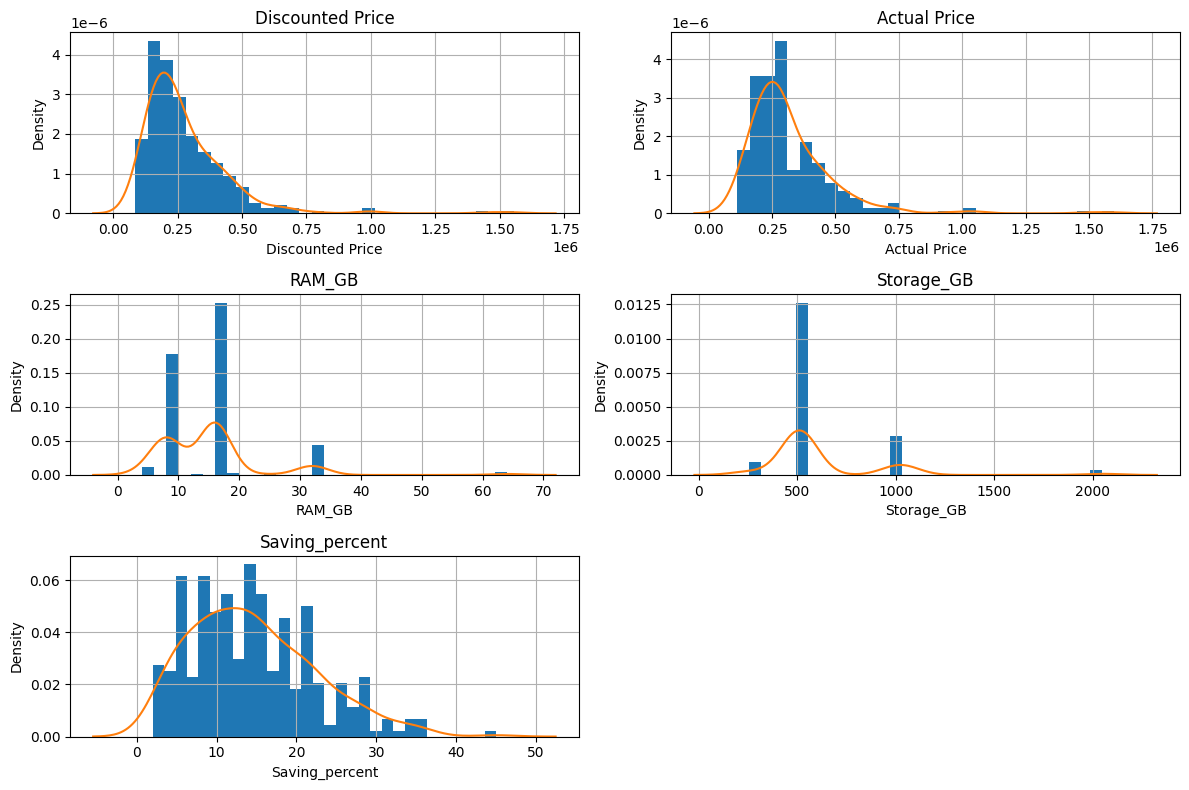

In [95]:
df_qnt.hist(
    bins=30,
    figsize=(12,8),
    density=True
)

for ax in plt.gcf().axes:
    for col in df_qnt.columns:
        if ax.get_title() == col:
            sns.kdeplot(df_qnt[col], ax=ax)

plt.tight_layout()
plt.show()


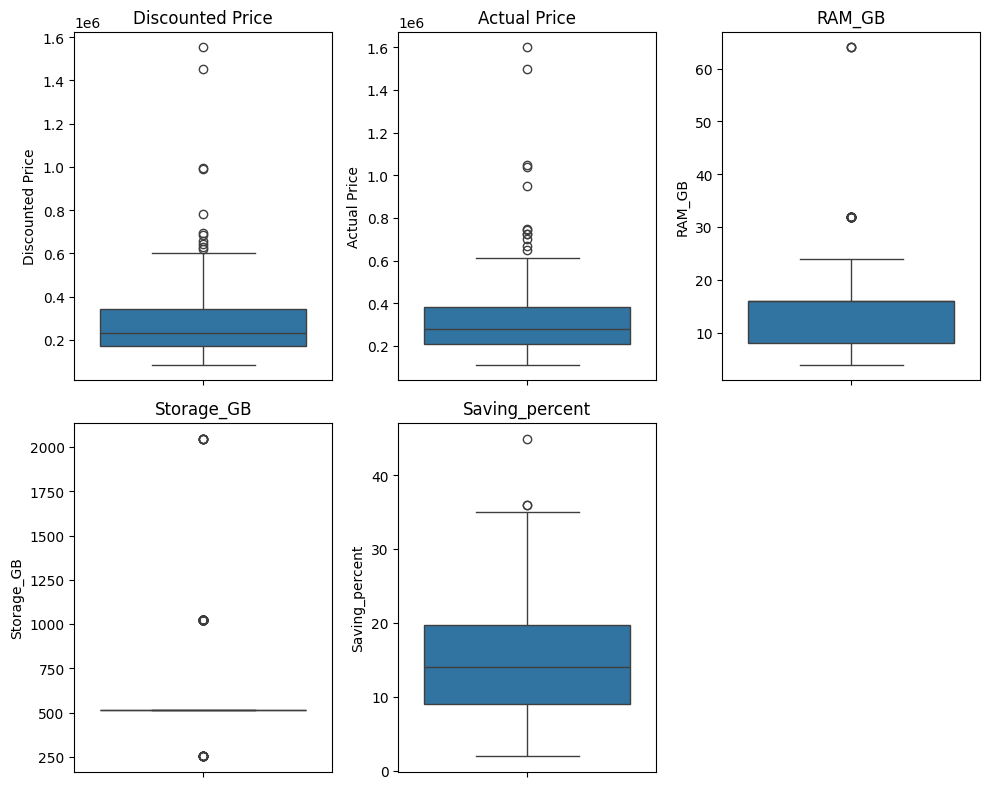

In [96]:
cols = df_qnt.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(10, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_qnt[col])
    plt.title(col)

plt.tight_layout()
plt.show()


The variables do not follow a normal distribution. Most distributions are right-skewed, with a concentration of values at lower ranges and a few extreme high values acting as outliers, especially for the price.

## 2.2 Qualitative variables 

In [97]:
df_cat = df1[['Brand', 'Core']]
df_cat.head()


,Brand,Core
0,apple,m1
1,apple,m4
2,asus,ultra7
3,lenovo,ultra7
4,lenovo,ryzen7


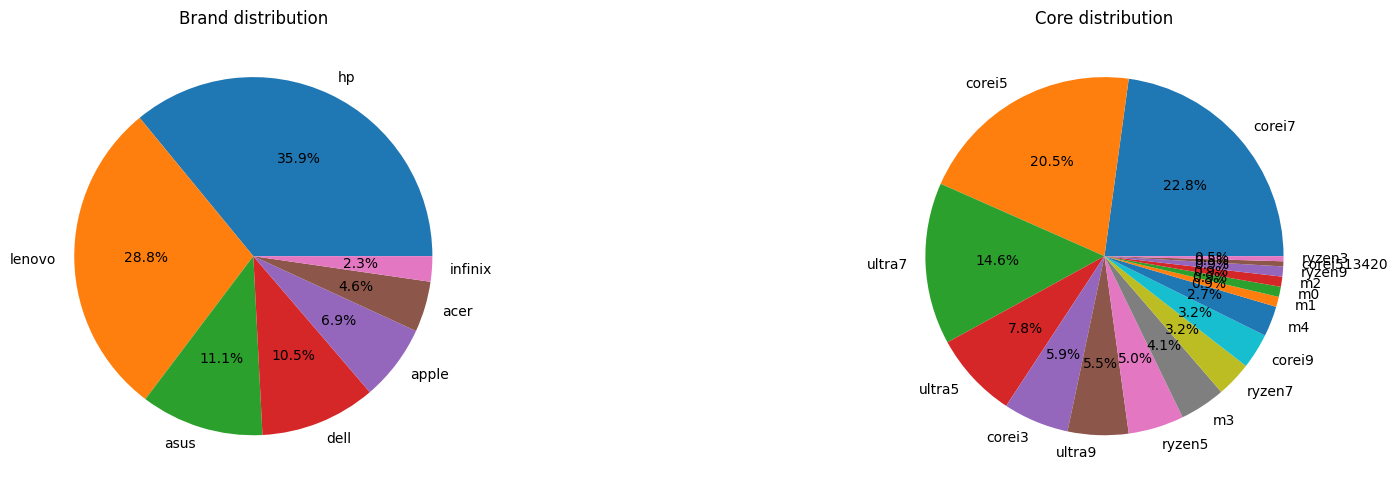

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Brand
df1['Brand'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0]
)
axes[0].set_title('Brand distribution')
axes[0].set_ylabel('')

# Core
df1['Core'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1]
)
axes[1].set_title('Core distribution')
axes[1].set_ylabel('')


plt.tight_layout()
plt.show()


The brand distribution is dominated by a few major manufacturers, with HP and Lenovo representing a large share of the dataset, while many other brands appear marginally.

Processor types are mainly concentrated around Intel Core i5 and i7, indicating a focus on mid- to high-range laptops.

## 2.3 Multivariate analysis

* Normalization

In [99]:
scaler = StandardScaler()
df_qnt_scaled = pd.DataFrame(
    scaler.fit_transform(df_qnt),
    columns=df_qnt.columns
)

df_qnt_scaled.head()

,Discounted Price,Actual Price,RAM_GB,Storage_GB,Saving_percent
0,-0.434481,-0.348523,-0.811980,-1.239362,0.826049
1,0.025868,0.175067,0.141824,-0.355341,0.569559
2,0.049325,0.061243,0.141824,-0.355341,-0.199911
3,0.061054,0.118155,0.141824,-0.355341,0.056579
4,-0.765815,-0.820893,-0.811980,-0.355341,0.184824


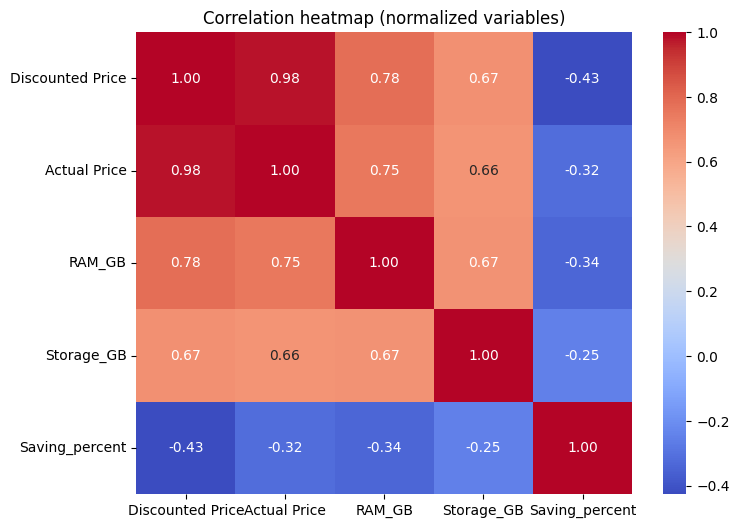

In [100]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_qnt_scaled.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation heatmap (normalized variables)')
plt.show()


- Strong relationship between discounted and actual prices, which is expected and intuitive.

- The correlation between actual price and saving percentage is low and negative, meaning that higher-priced laptops tend to have lower relative discounts, although the relationship remains weak.

- RAM and storage are positively correlated with price, indicating that higher hardware specifications generally correspond to higher prices.

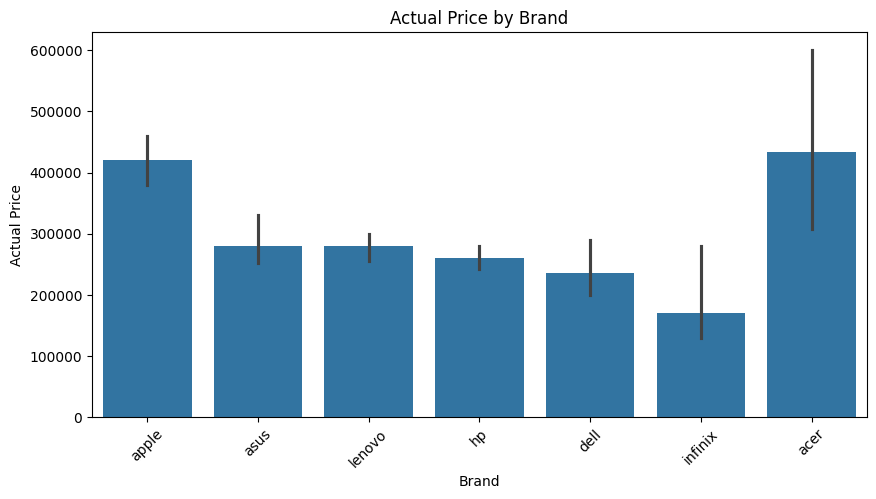

In [101]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df1,
    x='Brand',
    y='Actual Price',
    estimator='median'
)
plt.title('Actual Price by Brand')
plt.xticks(rotation=45)
plt.show()


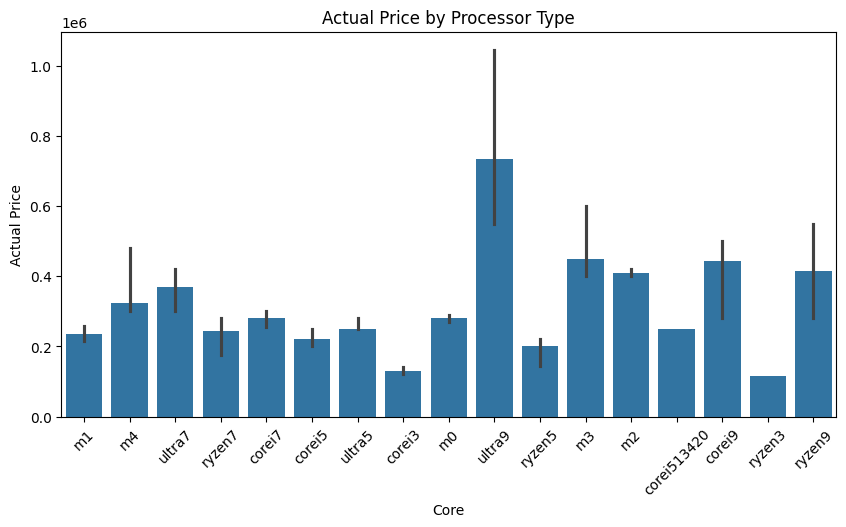

In [102]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df1,
    x='Core',
    y='Actual Price',
    estimator='median'
)
plt.title('Actual Price by Processor Type')
plt.xticks(rotation=45)
plt.show()


- Price differ across brands, with some brands generally associated with higher price ranges, while others tend to appear in lower-priced segments : 
    * Apple and Acer laptops mostly appear in higher price ranges (around 400k–450k) 
    * Infinix mainly found in lower ranges (around 150k–250k).

- Price also vary across processor types, with higher-end processors appearing more frequently in higher price ranges.

# 3. Modeling

## 3.1 Unsupervised Learning – K-Means Clustering


### a. Selection of the number of clusters (K)

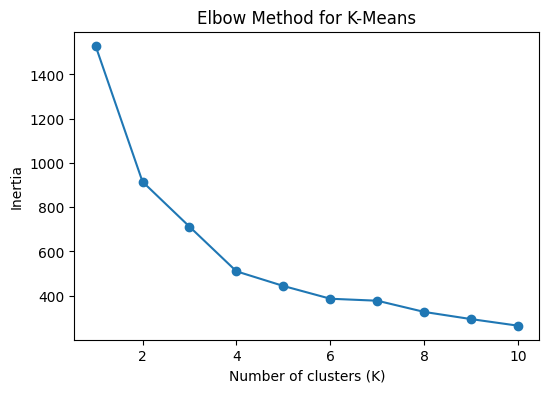

In [103]:
inertia = []

K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_qnt_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.show()


K = 4 is the best choice.

### b. Model training and cluster assignment

In [104]:
# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42)
df1['Cluster'] = kmeans.fit_predict(df_qnt_scaled)

# Check cluster sizes
df1['Cluster'].value_counts()


Cluster
2    142
1    115
0     45
3      4
Name: count, dtype: int64

In [105]:
# Select 2 examples per cluster 
examples_per_cluster = (
    df1
    .groupby('Cluster', group_keys=False)
    .apply(lambda x: x.sample(2, random_state=42))
)

# Columns to display 
cols_to_show = [
    'Cluster',
    'Brand',
    'Core',
    'Actual Price',
    'Discounted Price',
    'RAM_GB',
    'Storage_GB'
]

examples_per_cluster[cols_to_show]


C:\Users\zakar\AppData\Local\Temp\ipykernel_21624\214209566.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(2, random_state=42))


,Cluster,Brand,Core,Actual Price,Discounted Price,RAM_GB,Storage_GB
276,0,acer,ultra9,550000.0,430999.0,32.0,1024.0
163,0,lenovo,ultra7,449999.0,396999.0,16.0,1024.0
225,1,infinix,corei7,169999.0,119999.0,8.0,512.0
6,1,dell,NaN,249999.0,169999.0,8.0,256.0
290,2,dell,corei7,219999.0,189999.0,16.0,512.0
43,2,hp,ryzen5,219999.0,194999.0,8.0,512.0
118,3,acer,ultra9,1050000.0,995999.0,64.0,1024.0
165,3,lenovo,ultra9,1599900.0,1552999.0,64.0,2048.0


### c. Cluster visualization (3D)

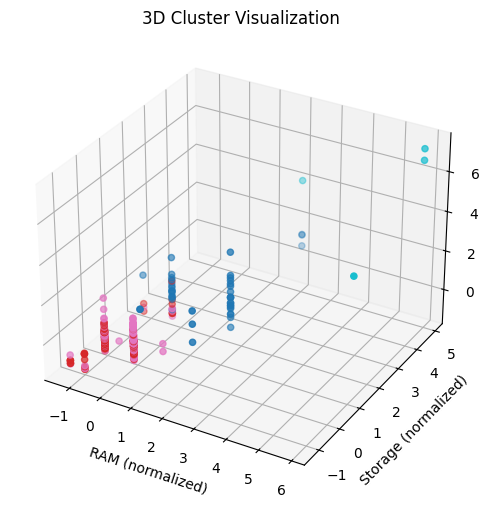

In [106]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_qnt_scaled['RAM_GB'],
    df_qnt_scaled['Storage_GB'],
    df_qnt_scaled['Actual Price'],
    c=df1['Cluster'],
    cmap='tab10'
)

ax.set_xlabel('RAM (normalized)')
ax.set_ylabel('Storage (normalized)')
ax.set_zlabel('Actual Price (normalized)')
ax.set_title('3D Cluster Visualization')

plt.show()


### D. Describing and profiling

In [107]:
df1.groupby('Cluster')[[
    'Actual Price',
    'Saving_percent',
    'RAM_GB',
    'Storage_GB'
]].mean()

,Actual Price,Saving_percent,RAM_GB,Storage_GB
Cluster,,,,
0,5.251998e+05,9.377778,25.155556,1035.377778
1,2.330945e+05,22.400000,10.747826,520.904348
2,2.961793e+05,10.147887,13.661972,524.619718
3,1.297450e+06,4.000000,56.000000,1792.000000


In [108]:
df1.groupby('Cluster')[[
    'Actual Price',
    'RAM_GB',
    'Storage_GB'
]].median()

,Actual Price,RAM_GB,Storage_GB
Cluster,,,
0,499999.0,32.0,1024.0
1,220000.0,8.0,512.0
2,280000.0,16.0,512.0
3,1274950.0,64.0,2048.0


* Cluster 0 :
    - High specifications ( 32 GB RAM )
    - High prices
    * High-performance laptops

* Cluster 1 :
    - Low specifications
    - Low-range pricing
    * Entry-level laptops

* Cluster 2 :
    - Balanced specifications (16 GB RAM)
    - Low to Mid range pricing
    * Mid-range laptops ( Good value )

* Cluster 3 :
    - Very high specifications
    - Very high prices
    * Premium (Gaming) laptops


In [109]:
df1 = df1.drop(columns=['Cluster'])


## 3.2 Supervised Learning

### 1. Price prediction (Regression)

Define target and features

In [110]:
# Target
y = df_qnt['Actual Price']

# Features 
# Dropped discounted price, because it's linearly related to the actual price : Discounted Price = Actual Price × (1 − Saving_percent / 100)
X = df_qnt.drop(columns=[
    'Actual Price',
    'Discounted Price',
])


Test Train Split

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head(3)

,RAM_GB,Storage_GB,Saving_percent
213,32.0,1024.0,5.0
244,8.0,512.0,27.0
75,8.0,512.0,26.0


Model training

In [112]:
model = LinearRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)

# Display results
results = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': prediction
})
print(results.head(10))


     Actual Value  Predicted Value
182      200000.0    312674.773254
154      199999.0    243157.389315
111      250000.0    321982.894340
203      450000.0    518417.742253
60       275000.0    312674.773254
9        174999.0    303366.652167
119      570000.0    403549.951193
157      250000.0    241606.035801
167      375000.0    415960.779309
33       270000.0    308020.712710


In [113]:
# Compute Mean Squared Error (MSE)
mse = metrics.mean_squared_error(y_test, prediction)

# Compute Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Compute R-squared (R²)
r2 = metrics.r2_score(y_test, prediction)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R² Score:', r2)


Mean Squared Error: 11908874365.476086
Root Mean Squared Error: 109127.78915324953
R² Score: 0.5440588103155465


### 2. Price classification

Create price classes using K-Means in order to split laptop prices into 3 categories.

K-Means is used instead of fixed thresholds or quantiles because it identifies natural price segments by minimizing within-cluster variance.


In [114]:
kmeans_price = KMeans(n_clusters=3, random_state=42)

df1['Price_Class'] = kmeans_price.fit_predict(df_qnt_scaled[['Actual Price']])

# Mean price per class
df1.groupby('Price_Class')['Actual Price'].mean().round(0)




Price_Class
0     239199.0
1    1227960.0
2     474723.0
Name: Actual Price, dtype: float64

* 0 : Cheap
* 1 : Expensive
* 2 : Average

In [115]:
# Map price classes to labels
price_class_map = {
    0: 'Cheap',
    1: 'Expensive',
    2: 'Average'
}

df1['Price_Class_Label'] = df1['Price_Class'].map(price_class_map)


df1 = df1.drop(columns=['Price_Class', 'Model'])

df1.head()


,Discounted Price,Actual Price,Brand,Core,RAM_GB,Storage_GB,Saving_percent,Price_Class_Label
0,203499.0,258000.0,apple,m1,8.0,256.0,21.0,Cheap
1,281999.0,350000.0,apple,m4,16.0,512.0,19.0,Cheap
2,285999.0,330000.0,asus,ultra7,16.0,512.0,13.0,Cheap
3,287999.0,340000.0,lenovo,ultra7,16.0,512.0,15.0,Cheap
4,146999.0,175000.0,lenovo,ryzen7,8.0,512.0,16.0,Cheap


Preparing an adapted DataFrame

In [119]:
# Quantitative columns 
df_qnt_scaled_df = df_qnt_scaled.copy()
df_qnt_scaled_df.index = df1.index 

# Build df2 with normalized quantitative features + categorical + target
df2 = pd.concat([
    df_qnt_scaled_df.drop(columns=['Actual Price', 'Discounted Price'], errors='ignore'),
    df1[['Brand', 'Core', 'Price_Class_Label']]
], axis=1)

df2.head()


,RAM_GB,Storage_GB,Saving_percent,Brand,Core,Price_Class_Label
0,-0.811980,-1.239362,0.826049,apple,m1,Cheap
1,0.141824,-0.355341,0.569559,apple,m4,Cheap
2,0.141824,-0.355341,-0.199911,asus,ultra7,Cheap
3,0.141824,-0.355341,0.056579,lenovo,ultra7,Cheap
4,-0.811980,-0.355341,0.184824,lenovo,ryzen7,Cheap


Define target and features

In [120]:
# Target
y = df2['Price_Class_Label']

# Features 
X = df2.drop(columns=['Price_Class_Label'])

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)




Training models

In [118]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': svm.SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = metrics.accuracy_score(y_test, y_pred)

accuracy_df = pd.DataFrame.from_dict(
    results, orient='index', columns=['Accuracy']
).sort_values(by='Accuracy', ascending=False)

accuracy_df


,Accuracy
Logistic Regression,0.838710
KNN,0.806452
Random Forest,0.806452
SVM,0.806452
Decision Tree,0.741935
Naive Bayes,0.403226
